# OCR feasibility check &mdash; armyradio.ch corpus

**Goal.** The PDFs in `corpus/` are pure image scans of historical Swiss army radio manuals (1940s&ndash;80s, mostly typewritten German). They have **no embedded text layer** &mdash; `pdftotext` returns zero bytes. Before we commit to using them as the RAG corpus for Track 1, we want to confirm that off-the-shelf OCR can extract the text well enough to be useful.

**Approach.** Render each PDF page to an image with PyMuPDF, then run EasyOCR on the image. EasyOCR is pure-pip (no system Tesseract install needed) and supports German out of the box.

**What this notebook does.**
1. Render the first sample PDF to images.
2. Show you a preview of one rendered page.
3. Load the EasyOCR model (downloads ~200 MB on first run).
4. OCR a single page so you can eyeball the output quality.
5. OCR the whole document, save it to `notebooks/output/<stem>.txt`.
6. Repeat on a second PDF for comparison.

**Kernel.** Use the `Python (hackathon-armasuisse)` kernel created from `.venv` at the repo root.

In [1]:
from pathlib import Path
import time
import io

import fitz  # PyMuPDF, used to render PDF pages to images
import numpy as np
from PIL import Image

REPO = Path(r"c:/Users/Alexander/OneDrive/RIL/Code/hackathon-armasuisse.github.io")
CORPUS = REPO / "corpus"
OUTPUT = REPO / "notebooks" / "output"
OUTPUT.mkdir(parents=True, exist_ok=True)

available = sorted(CORPUS.glob("*.pdf"))
print(f"Repo:    {REPO}")
print(f"Corpus:  {CORPUS} ({len(available)} PDFs available)")
print(f"Output:  {OUTPUT}")
for p in available[:5]:
    print(f"  - {p.name}")

Repo:    c:\Users\Alexander\OneDrive\RIL\Code\hackathon-armasuisse.github.io
Corpus:  c:\Users\Alexander\OneDrive\RIL\Code\hackathon-armasuisse.github.io\corpus (67 PDFs available)
Output:  c:\Users\Alexander\OneDrive\RIL\Code\hackathon-armasuisse.github.io\notebooks\output
  - autophon-testgeraet-t107.pdf
  - das-telekryptogeraet-tc53.pdf
  - die-grosse-1-5-kw-funkstation.pdf
  - die-tragbare-leichte-funkstation-tl.pdf
  - e-600-autophon-e39-allgemeine-beschreibung-small.pdf


## Step 1 &mdash; render PDF pages to images

EasyOCR works on images, not PDFs. PyMuPDF's `Page.get_pixmap()` rasterises a page at any DPI we choose. **300 DPI** is the conventional sweet spot for OCR &mdash; lower than that and small text blurs; higher than that wastes time without much accuracy gain. Tune via the `dpi` argument if you find OCR is missing fine details on a particular document.

In [2]:
def render_pdf_pages(pdf_path: Path, dpi: int = 300, page_range=None):
    """Render PDF pages to a list of PIL.Image objects at the given DPI."""
    doc = fitz.open(pdf_path)
    pages = page_range if page_range is not None else range(doc.page_count)
    zoom = dpi / 72  # 72 is PDF's native DPI; multiplying by zoom gives the requested DPI
    matrix = fitz.Matrix(zoom, zoom)
    images = []
    for i in pages:
        page = doc.load_page(i)
        pix = page.get_pixmap(matrix=matrix, alpha=False)
        img = Image.frombytes("RGB", (pix.width, pix.height), pix.samples)
        images.append(img)
    doc.close()
    return images

SAMPLE_PDF_1 = CORPUS / "e-602-autophon-e44-manual-small.pdf"
doc = fitz.open(SAMPLE_PDF_1)
print(f"Sample PDF: {SAMPLE_PDF_1.name}")
print(f"Pages:      {doc.page_count}")
doc.close()

Sample PDF: e-602-autophon-e44-manual-small.pdf
Pages:      30


Rendered 3 pages, first page raster: (824, 587) px


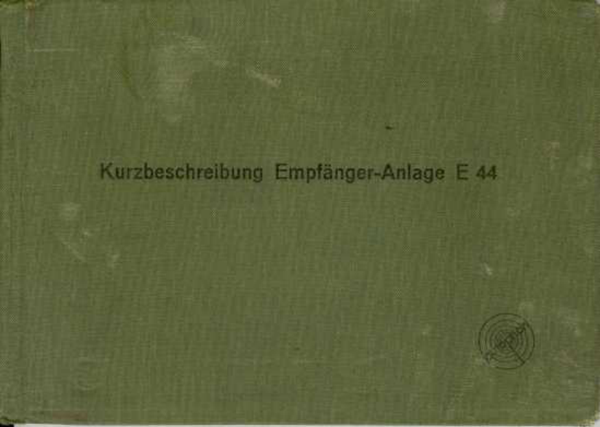

In [3]:
# Render the first 3 pages and preview the first one (downsampled for display)
preview_pages = render_pdf_pages(SAMPLE_PDF_1, dpi=300, page_range=range(3))
print(f"Rendered {len(preview_pages)} pages, first page raster: {preview_pages[0].size} px")

preview = preview_pages[0].copy()
preview.thumbnail((600, 800))
preview

## Step 2 &mdash; load the OCR reader

We pass two languages: `de` (German &mdash; the bulk of the documents) and `en` (English &mdash; some manuals are translations or use English part numbers). EasyOCR will use the appropriate model per detected text region.

**First run is slow:** weights are downloaded to `~/.EasyOCR/` (~200 MB total). Subsequent runs reuse the cached weights.

We pin `gpu=False` to keep this CPU-only. If you have a CUDA-capable GPU and a CUDA-enabled torch install, set `gpu=True` for ~10x speed.

In [4]:
import easyocr

print("Loading EasyOCR reader (downloads ~200 MB on first run)...")
t0 = time.time()
reader = easyocr.Reader(['de', 'en'], gpu=False)
print(f"Reader ready in {time.time() - t0:.1f}s")

Using CPU. Note: This module is much faster with a GPU.


Loading EasyOCR reader (downloads ~200 MB on first run)...
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteReader ready in 17.0s


## Step 3 &mdash; OCR a single page

`reader.readtext` returns either a list of `(bbox, text, confidence)` tuples (default) or just text strings (`detail=0`). Setting `paragraph=True` asks EasyOCR to group adjacent boxes into reading-order paragraphs, which is closer to what we want for RAG ingestion.

In [5]:
def ocr_image(reader, img: Image.Image) -> str:
    """Run EasyOCR on a PIL image and return text grouped into paragraphs."""
    arr = np.array(img)
    paragraphs = reader.readtext(arr, detail=0, paragraph=True)
    return "\n\n".join(paragraphs)

t0 = time.time()
page1_text = ocr_image(reader, preview_pages[0])
elapsed = time.time() - t0

print(f"Page 1 OCR took {elapsed:.1f}s, produced {len(page1_text)} chars\n")
print("--- first 400 chars of OCR output ---")
print(page1_text[:400])
print("--- end sample ---")

C:\Users\Alexander\OneDrive\RIL\Code\hackathon-armasuisse.github.io\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Page 1 OCR took 4.4s, produced 38 chars

--- first 400 chars of OCR output ---
Kurzbeschreibung Empfänger-Anlage E 44
--- end sample ---


## Step 4 &mdash; OCR the whole document

Now we wrap the per-page logic in a helper that:
- iterates every page,
- prefixes each page's text with a `--- page N of M ---` separator (useful for citation later),
- prints a progress line per page,
- writes the full transcript to a UTF-8 `.txt` file under `notebooks/output/`.

In [6]:
def ocr_pdf(pdf_path: Path, reader, dpi: int = 300, save_to: Path | None = None) -> str:
    """OCR every page of a PDF and return the concatenated text."""
    doc = fitz.open(pdf_path)
    n = doc.page_count
    doc.close()

    parts = []
    t_start = time.time()
    # We render lazily one page at a time to keep memory bounded for long documents
    for i in range(n):
        [img] = render_pdf_pages(pdf_path, dpi=dpi, page_range=[i])
        text = ocr_image(reader, img)
        parts.append(f"\n\n--- page {i+1} of {n} ---\n\n{text}")
        print(f"  page {i+1}/{n}: {len(text):>5} chars  ({time.time() - t_start:.1f}s elapsed)")
    full = "".join(parts).strip()

    if save_to is not None:
        save_to.write_text(full, encoding="utf-8")
        print(f"\nWrote {len(full)} chars to {save_to}")
    return full

In [7]:
# Run on the first sample PDF
out1 = OUTPUT / (SAMPLE_PDF_1.stem + ".txt")
text1 = ocr_pdf(SAMPLE_PDF_1, reader, dpi=300, save_to=out1)

print(f"\nTotal: {len(text1)} chars across {len(text1.splitlines())} lines")
print("\n--- first 300 chars of full transcript ---")
print(text1[:300])

  page 1/30:    38 chars  (4.0s elapsed)
  page 2/30:    90 chars  (9.0s elapsed)
  page 3/30:   499 chars  (19.5s elapsed)
  page 4/30:   693 chars  (33.3s elapsed)
  page 5/30:   793 chars  (47.3s elapsed)
  page 6/30:   665 chars  (60.8s elapsed)
  page 7/30:  1409 chars  (79.3s elapsed)
  page 8/30:   930 chars  (92.9s elapsed)
  page 9/30:   898 chars  (105.6s elapsed)
  page 10/30:   898 chars  (119.8s elapsed)
  page 11/30:   796 chars  (131.0s elapsed)
  page 12/30:   708 chars  (141.9s elapsed)
  page 13/30:   845 chars  (154.7s elapsed)
  page 14/30:  1167 chars  (170.5s elapsed)
  page 15/30:   823 chars  (183.2s elapsed)
  page 16/30:   734 chars  (194.0s elapsed)
  page 17/30:   900 chars  (207.1s elapsed)
  page 18/30:   835 chars  (220.7s elapsed)
  page 19/30:   854 chars  (236.6s elapsed)
  page 20/30:   514 chars  (245.9s elapsed)
  page 21/30:   554 chars  (260.3s elapsed)
  page 22/30:  1088 chars  (288.8s elapsed)
  page 23/30:   156 chars  (297.3s elapsed)
  page 

## Step 5 &mdash; second sample for comparison

Different documents, different vintages, different scan quality &mdash; we want to see how robust the same pipeline is across the corpus.

In [8]:
SAMPLE_PDF_2 = CORPUS / "e-600-autophon-e39-manual-small.pdf"
out2 = OUTPUT / (SAMPLE_PDF_2.stem + ".txt")
text2 = ocr_pdf(SAMPLE_PDF_2, reader, dpi=300, save_to=out2)

print(f"\nTotal: {len(text2)} chars across {len(text2.splitlines())} lines")
print("\n--- first 300 chars of full transcript ---")
print(text2[:300])

  page 1/34:    72 chars  (4.8s elapsed)
  page 2/34:    72 chars  (8.9s elapsed)
  page 3/34:  1370 chars  (71.3s elapsed)
  page 4/34:  1168 chars  (136.2s elapsed)
  page 5/34:  1157 chars  (184.8s elapsed)
  page 6/34:  1246 chars  (250.7s elapsed)
  page 7/34:  1533 chars  (318.1s elapsed)
  page 8/34:  1722 chars  (383.2s elapsed)
  page 9/34:  1963 chars  (432.4s elapsed)
  page 10/34:  1810 chars  (477.3s elapsed)
  page 11/34:  1951 chars  (524.4s elapsed)
  page 12/34:  1853 chars  (572.9s elapsed)
  page 13/34:  1379 chars  (606.7s elapsed)
  page 14/34:  1845 chars  (658.4s elapsed)
  page 15/34:    80 chars  (664.0s elapsed)
  page 16/34:   219 chars  (680.8s elapsed)
  page 17/34:   278 chars  (699.9s elapsed)
  page 18/34:   215 chars  (714.8s elapsed)
  page 19/34:  1588 chars  (751.8s elapsed)
  page 20/34:  1543 chars  (787.3s elapsed)
  page 21/34:  1852 chars  (833.4s elapsed)
  page 22/34:  1819 chars  (873.1s elapsed)
  page 23/34:  1872 chars  (917.2s elapsed)
  

## Notes &mdash; tradeoffs and what to tune

Things you can adjust if quality is unsatisfying on a particular document:

| Knob | Default | When to change |
|---|---|---|
| `dpi` in `render_pdf_pages` | 300 | Bump to 400&ndash;600 if small subscripts / footnotes are lost; drop to 200 if speed matters more than precision. |
| `paragraph=True` in `readtext` | on | Turn off if the document is mostly tables &mdash; paragraph-grouping can scramble row order. |
| `gpu=False` | off | Set `True` and install CUDA-enabled torch for ~10x throughput on long docs. |
| Languages `['de', 'en']` | both | Drop to `['de']` if a document is purely German; keeps the model focused. |

**Alternative engines worth knowing about**, in rough order of effort vs. quality:

- **Tesseract via `ocrmypdf`** &mdash; the de-facto standard. `ocrmypdf --language deu input.pdf output.pdf` produces a searchable PDF *and* extracted text in one shot, with deskew/clean built in. Needs a system Tesseract install but is generally the best CPU-only option for typewritten European text. Recommended for the hackathon's serious bulk run.
- **PaddleOCR** &mdash; competitive accuracy, layout analysis included, heavier models (~500 MB).
- **Cloud OCR (AWS Textract, Google Document AI, Azure Read)** &mdash; best raw quality especially on noisy scans, but usage-priced and sends documents off-machine. Only relevant if local options aren't good enough.

**Things OCR will not solve for you**:

- **Schematics and circuit diagrams** &mdash; pure graphics with isolated labels. The text labels do come through but their spatial relationship to the diagram is lost. For RAG over schematics you need either a layout-aware OCR (Surya, PaddleOCR) or a vision-language model in the retrieval pipeline.
- **Tables of measurements** &mdash; reading-order OCR scrambles columns. Either set `paragraph=False` and reconstruct rows from bounding boxes, or use a table-extraction tool (e.g. `camelot`, `pdfplumber` in image mode).
- **Handwritten annotations** in older scans &mdash; expect 0-50% accuracy. EasyOCR's printed-text models won't do well on cursive.